# Proyecto Deep Learning Spotify: Tarea 3 - Modelo 10: Red Swish

## Configuración del entorno

In [ ]:
%pip install -r ../requirements.txt

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



sys.path.append(os.path.abspath('..'))
from models.T3_M10_red_swish import crear_modelo

In [12]:
df = pd.read_csv(r'..\data\data.csv')

df_limpio = df[
    (df['duration_ms'] > 40000) & 
    (df['speechiness'] < 0.90) & 
    (df['tempo'] > 0)
].copy()

cols_to_drop = ['popularity', 'id', 'name', 'artists', 'id_artists', 'release_date', 'mode']
X = df_limpio.drop(columns=cols_to_drop, errors='ignore')
y = df_limpio['popularity']

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [15]:
modelo_nn = crear_modelo(X_train_scaled.shape[1])

print("RESUMEN DE LA ARQUITECTURA M10 (SWISH + ADAMW)")
modelo_nn.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=0.00001,
    verbose=1
)

historia = modelo_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=500,
    batch_size=256,
    verbose=1,
    callbacks=[early_stop, reduce_lr]
)

RESUMEN DE LA ARQUITECTURA M10 (SWISH + ADAMW)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,121 (51.25 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 473.5881 - mae: 15.5703 - val_loss: 135.1493 - val_mae: 8.7962 - learning_rate: 0.0010
Epoch 2/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 123.3633 - mae: 8.0172 - val_loss: 110.1113 - val_mae: 7.2670 - learning_rate: 0.0010
Epoch 3/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 111.9486 - mae: 7.6090 - val_loss: 104.0250 - val_mae: 7.1536 - learning_rate: 0.0010
Epoch 4/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 109.6678 - mae: 7.5142 - val_loss: 103.1932 - val_mae: 7.1992 - learning_rate: 0.0010
Epoch 5/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 108.6036 - mae: 7.4766 - val_loss: 102.6839 - val_mae: 7.1535 - learning_rate: 0.0010
Epoch 6/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 106.8239 - mae: 7.4165 - val_loss: 101.1990 - val_mae: 7.0575 - learning_rate: 0.0010
Epoch 7/500
454/454 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 106.3563 - mae: 7.3855 - val_loss: 100.1883 - val_mae

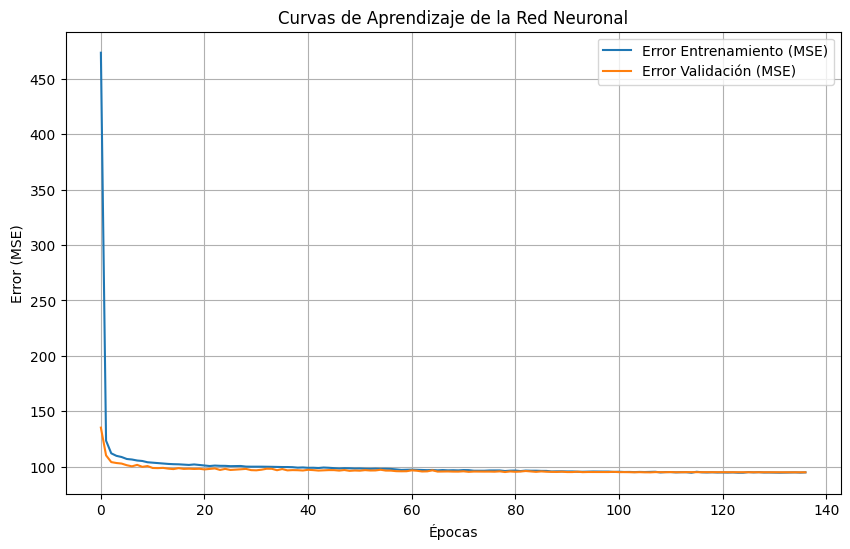

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(historia.history['loss'], label='Error Entrenamiento (MSE)')
plt.plot(historia.history['val_loss'], label='Error Validación (MSE)')
plt.title('Curvas de Aprendizaje de la Red Neuronal')
plt.xlabel('Épocas')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
def evaluar_red(modelo, X_data, y_true, nombre_conjunto):
    y_pred = modelo.predict(X_data, verbose=0).flatten()
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Resultados en {nombre_conjunto} ---")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}\n")

print("EVALUACIÓN RED NEURONAL\n")

evaluar_red(modelo_nn, X_train_scaled, y_train, "ENTRENAMIENTO")
evaluar_red(modelo_nn, X_val_scaled, y_val, "VALIDACIÓN")
evaluar_red(modelo_nn, X_test_scaled, y_test, "TEST")

EVALUACIÓN RED NEURONAL

--- Resultados en ENTRENAMIENTO ---
MSE:  91.36
RMSE: 9.56
R²:   0.8037

--- Resultados en VALIDACIÓN ---
MSE:  94.74
RMSE: 9.73
R²:   0.7972

--- Resultados en TEST ---
MSE:  89.97
RMSE: 9.49
R²:   0.8047

